Homework 2:Anlaysis 1 - Break Even

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from whatif import Model
from whatif import get_sim_results_df

In [16]:
#Creating the base model
class SingleProductSPF(Model):
    """This is the base model for the single price function"""
    def __init__(self, fixed_cost=5000, var_cost=100, selling_price=115, spf_constant=4900, spf_linear=-35, spf_quadratic=.06):
        self.fixed_cost = fixed_cost
        self.var_cost = var_cost
        self.selling_price = selling_price
        self.spf_constant = spf_constant
        self.spf_linear = spf_linear
        self.spf_quadratic = spf_quadratic

    def demand(self):
        """Calculating the demand using the selling price function"""
        demand = (self.spf_constant + self.spf_linear * self.selling_price + self.spf_quadratic * self.selling_price ** 2 )
        return demand

    def total_variable_cost(self):
        """Calculating the total variable cost"""
        return self.var_cost * self.demand()

    def total_cost(self):
        """Calculating the total cost"""
        return self.fixed_cost + self.total_variable_cost()

    def revenue(self):
        """Calculating the revenue"""
        return self.selling_price * self.demand()

    def profit(self):
        """Calculating the profit"""
        return self.revenue() - self.total_cost()
        

In [17]:
#Quick check to view results
model_check = SingleProductSPF()
print(f"Demand: {model_check.demand():.2f}")
print(f"Total Variable Cost: {model_check.total_variable_cost():.2f}")
print(f"Total Cost: {model_check.total_cost():.2f}")
print(f"Revenue: {model_check.revenue():.2f}")
print(f"Profit: {model_check.profit():.2f}")

Demand: 1668.50
Total Variable Cost: 166850.00
Total Cost: 171850.00
Revenue: 191877.50
Profit: 20027.50


1A - Created the base model above and ran a check to ensure the SingleProductSPF has the correct selling price of 115, demand is 1668, and profit is 20028 with the exceptions of rounding

In [20]:
#1B Create One-Way table

##using model 1
model_1 = SingleProductSPF()

##creating ranges
model_1_range = {"selling_price": np.arange(80, 141,10)}

##creating the data table
model_1_dt = model_1.data_table(model_1_range, outputs=["profit", "demand"])

##check the results
model_1_dt



,selling_price,profit,demand
0,80,-54680.0,2484.0
1,90,-27360.0,2236.0
2,100,-5000.0,2000.0
3,110,12760.0,1776.0
4,120,26280.0,1564.0
5,130,35920.0,1364.0
6,140,42040.0,1176.0


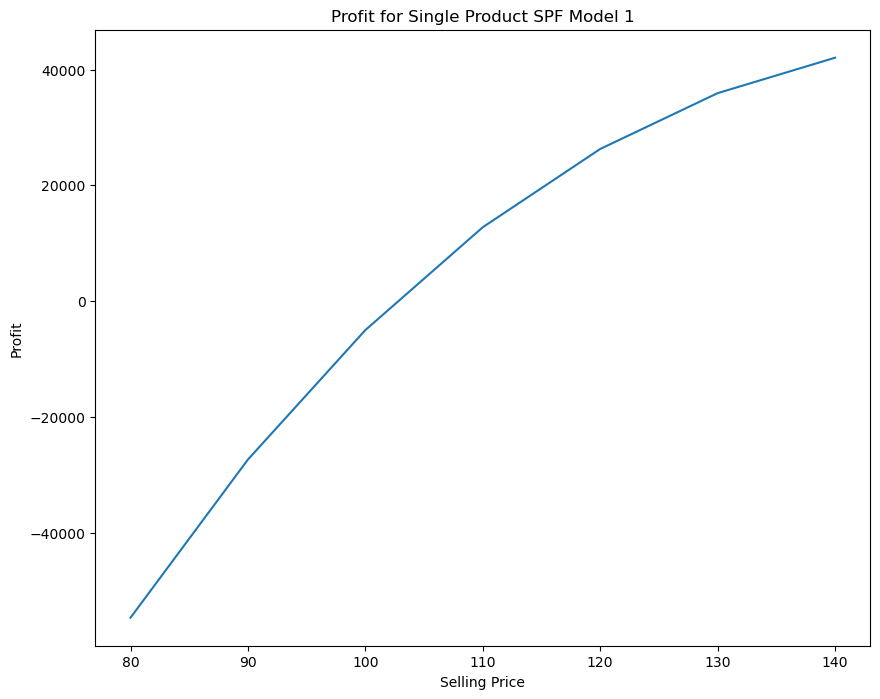

In [21]:
##creating a graph to visualize results
model_1_dt_plot = model_1_dt.plot(kind="line",x="selling_price",y="profit",figsize=(10,8),legend=False)

plt.title("Profit for Single Product SPF Model 1")
plt.xlabel("Selling Price")
plt.ylabel("Profit")
plt.show()


1B - Created a one way table of selling price, demand and profit then generated a graph to visualize results.
the shape appears to be pretty linear as the selling price increases the demand profit increases as well however not
exactly at a constant rate. The profit does appear to be increase gradually less although overall increasing as selling price increases

In [22]:
#1C - Break Even
model_2 = SingleProductSPF()

#find break even price
model_2_break_even_price = model_2.goal_seek(obj_fn="profit", target=0, by_changing="selling_price", a=80, b=140)

#display result
model_2_break_even_price



102.57578606424767

In [24]:
##check results
model_2.selling_price = model_2_break_even_price
print(f"Break Even Selling Price: {model_2_break_even_price:.2f}")
print(f"Break Even Demand: {model_2.demand():.2f}")
print(f"Break Even Profit: {model_2.profit():.2f}")

Break Even Selling Price: 102.58
Break Even Demand: 1941.16
Break Even Profit: 0.00


1C - used goal seek to find break even selling price of 102.58 meaning once the selling price got to that amount
there was enough demand not no longer be at a loss. Hypothetically based on this information and the graph seen previously if we were to increase are selling price from this point the profit would from here on be positive.

In [25]:
#1D 2-Way Data Table
model_3 = SingleProductSPF()

##create ranges for both price and variable production cost
model_3_range = {"selling_price": np.arange(80, 141, 10), "var_cost": np.arange(85, 111, 5)}

##creating 2 way data table
model_3_dt = model_3.data_table(model_3_range, outputs=["profit", "total_cost"])

##check dt result
model_3_dt

                 

,selling_price,var_cost,profit,total_cost
0,80,85,-17420.0,216140.0
1,80,90,-29840.0,228560.0
2,80,95,-42260.0,240980.0
3,80,100,-54680.0,253400.0
4,80,105,-67100.0,265820.0
5,80,110,-79520.0,278240.0
6,90,85,6180.0,195060.0
7,90,90,-5000.0,206240.0
8,90,95,-16180.0,217420.0
9,90,100,-27360.0,228600.0


In [27]:
##figure out size to display visually in a graph
model_3_dt.shape

(42, 4)

In [28]:
##create a pivot for plot
model_3_dt_plot = model_3_dt.pivot(index="selling_price", columns="var_cost", values="profit")

##check the pivot plot results
model_3_dt_plot

var_cost,85,90,95,100,105,110
selling_price,,,,,,
80,-17420.0,-29840.0,-42260.0,-54680.0,-67100.0,-79520.0
90,6180.0,-5000.0,-16180.0,-27360.0,-38540.0,-49720.0
100,25000.0,15000.0,5000.0,-5000.0,-15000.0,-25000.0
110,39400.0,30520.0,21640.0,12760.0,3880.0,-5000.0
120,49740.0,41920.0,34100.0,26280.0,18460.0,10640.0
130,56380.0,49560.0,42740.0,35920.0,29100.0,22280.0
140,59680.0,53800.0,47920.0,42040.0,36160.0,30280.0


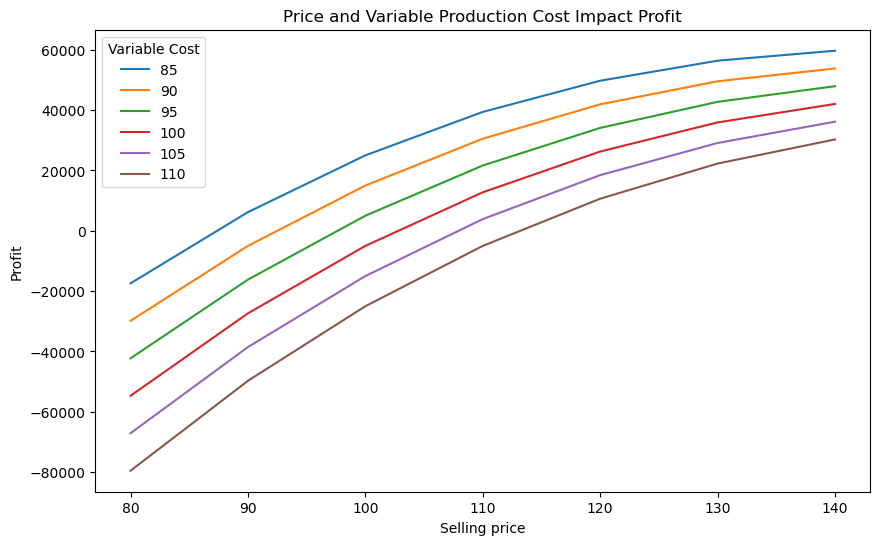

In [32]:
##plot the pivot 
model_3_dt_plot.plot(kind="line", figsize=(10, 6))

plt.title("Price and Variable Production Cost Impact Profit")
plt.xlabel("Selling price")
plt.ylabel("Profit")
plt.legend(title="Variable Cost")
plt.show()

1D - Created a pivot then a plot that shows the selling price and profit broken out over several different variable cost to see how different variable cost in combination with the selling price produce different profits. Of course it makes sense seeing here logically that the lowest variable cost of 85 yields the most profit with the same selling price compared to other variable cost.

In [35]:
#1E - Digging Deeper
model_4 = SingleProductSPF()

##find break even price
model_4_break_even_price = model_4.goal_seek(obj_fn="profit", target=0, by_changing="selling_price", a=80, b=250)

##Result
print(model_4_break_even_price)


None


1E - Goal Seek: The break even using goal seek returns None. I believe it returns this because there are two break even
points it identifies however since the endpoints dont provide clear brackets around one it results in a fail

In [36]:
##create range and 1 way data table
model_4_range = {"selling_price": np.arange(80, 251, 10)}

model_4_dt = model_4.data_table(model_4_range, outputs=["profit", "demand"])

##check data table results
model_4_dt


,selling_price,profit,demand
0,80,-54680.0,2484.0
1,90,-27360.0,2236.0
2,100,-5000.0,2000.0
3,110,12760.0,1776.0
4,120,26280.0,1564.0
5,130,35920.0,1364.0
6,140,42040.0,1176.0
7,150,45000.0,1000.0
8,160,45160.0,836.0
9,170,42880.0,684.0


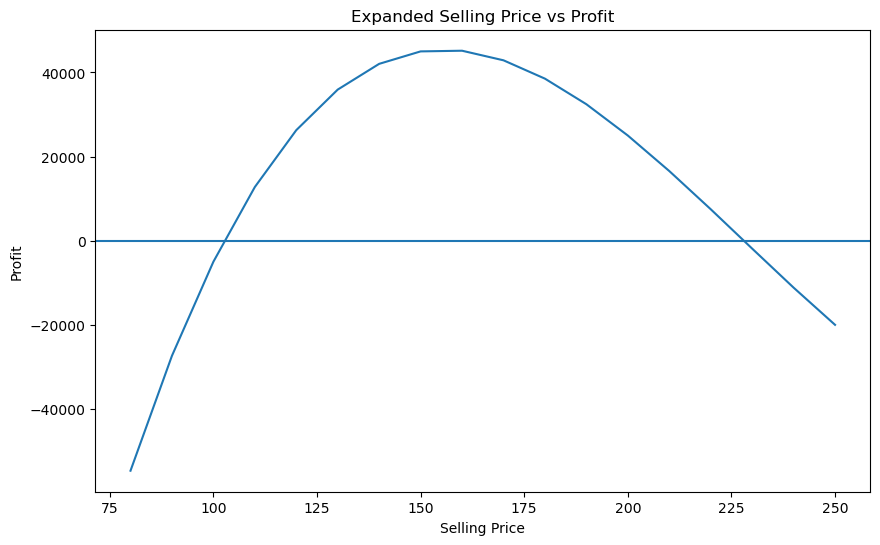

In [38]:
##plot the data table results
model_4_dt.plot(kind="line", x="selling_price", y="profit", figsize=(10,6), legend=False)

plt.title("Expanded Selling Price vs Profit")
plt.xlabel("Selling Price")
plt.ylabel("Profit")
plt.axhline(0)
plt.show()

1E - Data Table Plot: As I presumed, the goal seek found 2 target break even points which resulted why it said None.

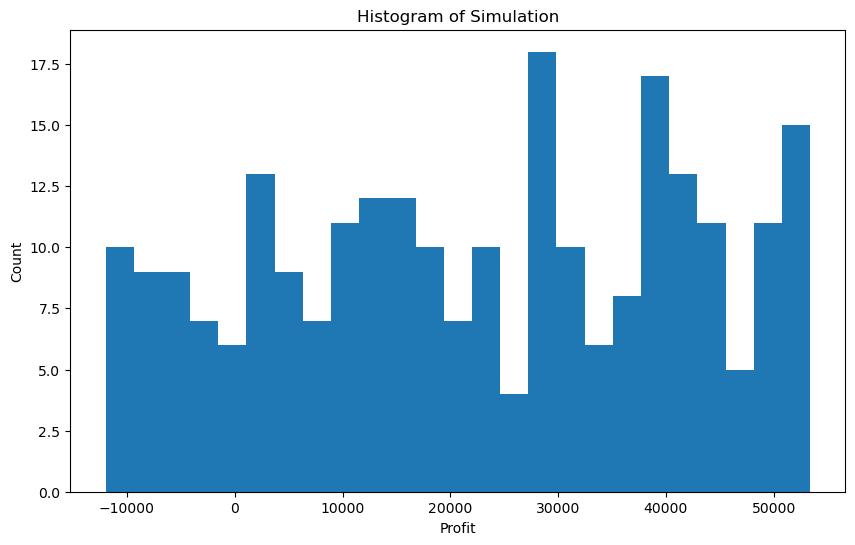

In [42]:
#1F - Simulation
model_5 = SingleProductSPF()

#Rep amount
num_reps = 250

#create rn generator
rand_num_generator = np.random.default_rng(4470)

##simulating variable cost
var_cost_simulation = rand_num_generator.uniform(80, 120, num_reps)

##random inputs dict
random_inputs = {"var_cost": var_cost_simulation}

##check outputs
simulation_outputs = ["profit"]

##get simulation results and run it
model_5_simulation_results = model_5.simulate(random_inputs=random_inputs,outputs=simulation_outputs,keep_random_inputs=True)

##converting to dataframe
model_5_simulation_results_df = get_sim_results_df(model_5_simulation_results)

##check results
model_5_simulation_results_df.head()

##create histogram
model_5_simulation_results_df["profit"].plot(kind="hist",bins=25,figsize=(10,6))

plt.title("Histogram of Simulation")
plt.xlabel("Profit")
plt.ylabel("Count")
plt.show()


In [44]:
##calculate probability of profit being negative
neg_profit_probability = (model_5_simulation_results_df["profit"] < 0).mean()

#check result
print(f"Probability prift is negative: {neg_profit_probability:.4f}")

Probability prift is negative: 0.1560


1F - Created a simulation using the simulate function and calculated based on this model that our probability that profit is negative is equal to 15.6%